## Logistic Regression 

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data:

In [1]:
import pandas as pd
import numpy as np

f_pumpkins = pd.read_csv('US-pumpkins.csv')


In [3]:
f_pumpkins.head(10)

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
5,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/12/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
6,BALTIMORE,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,170.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
7,BALTIMORE,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
8,BALTIMORE,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,10/1/16,160.0,170.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
9,BALTIMORE,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,10/1/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [4]:
f_pumpkins.info()

<class 'pandas.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   City Name        1757 non-null   str    
 1   Type             45 non-null     str    
 2   Package          1757 non-null   str    
 3   Variety          1752 non-null   str    
 4   Sub Variety      296 non-null    str    
 5   Grade            0 non-null      float64
 6   Date             1757 non-null   str    
 7   Low Price        1757 non-null   float64
 8   High Price       1757 non-null   float64
 9   Mostly Low       1654 non-null   float64
 10  Mostly High      1654 non-null   float64
 11  Origin           1754 non-null   str    
 12  Origin District  131 non-null    str    
 13  Item Size        1478 non-null   str    
 14  Color            1141 non-null   str    
 15  Environment      0 non-null      float64
 16  Unit of Sale     162 non-null    str    
 17  Quality          0 non-nu

In [ ]:
# Select the columns we want to use
s_pumpkins = f_pumpkins[['City Name', 'Package', 'Variety', 'Origin', 'Item Size', 'Color']]

# Drop rows with missing values
s_pumpkins.dropna(inplace=True)
s_pumpkins.head()


,City Name,Package,Variety,Origin,Item Size,Color
2,BALTIMORE,24 inch bins,HOWDEN TYPE,DELAWARE,med,ORANGE
3,BALTIMORE,24 inch bins,HOWDEN TYPE,VIRGINIA,med,ORANGE
4,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
5,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
6,BALTIMORE,36 inch bins,HOWDEN TYPE,MARYLAND,med,ORANGE


In [6]:
s_pumpkins['Color'].value_counts()

Color
ORANGE    835
WHITE     156
Name: count, dtype: int64

# Let's have a look to our data!

By visualising it with Seaborn

<Axes: xlabel='Variety', ylabel='count'>

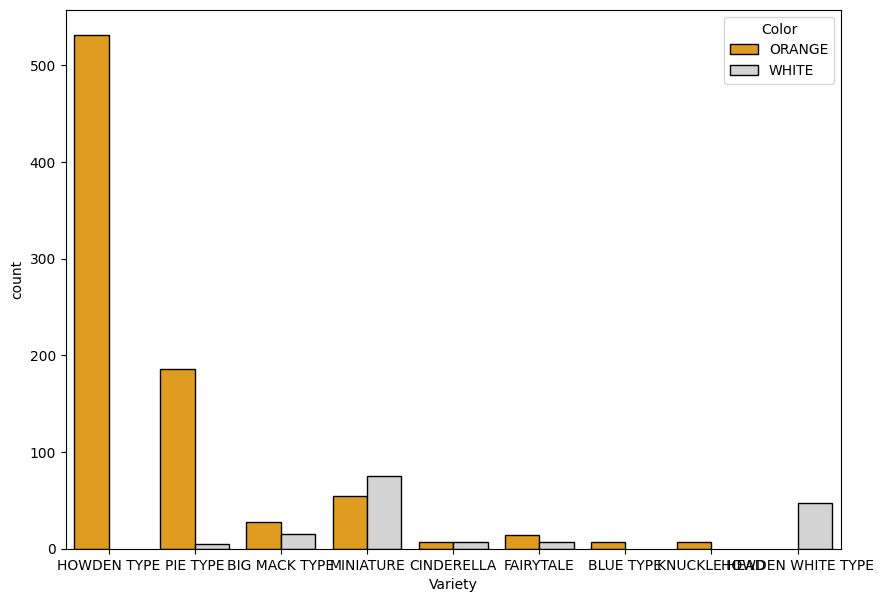

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Specify colors for each value of the hue variable
color_palette = {
    'ORANGE': 'orange',
    'WHITE': 'lightgray',
}

plt.figure(figsize=(10, 7))

sns.countplot(
    data=s_pumpkins,
    x='Variety',       
    hue='Color',
    palette=color_palette,
    edgecolor='black',
)


# Data pre-processing

Let's encode features and labels to better plot the data and train the model

In [17]:
# Let's look at the different values of the 'Item Size' column
s_pumpkins['Item Size'].unique()

<StringArray>
['med', 'lge', 'sml', 'xlge', 'med-lge', 'jbo', 'exjbo']
Length: 7, dtype: str

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
# Encode the 'Item Size' column using ordinal encoding
size_categories = [
    ['sml', 'med', 'med-lge', 'lge', 'xlge', 'jbo', 'exjbo']
]
ordinal_features = ['Item Size']
ordinal_encoder = OrdinalEncoder(
    categories=size_categories
)

In [20]:
from sklearn.preprocessing import OneHotEncoder
# Encode all the other features using one-hot encoding
categorical_features = ['City Name','Package','Variety','Origin']
categorical_encoder = OneHotEncoder(
    sparse_output=False
)

In [21]:
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer(transformers=[
     ('ord', ordinal_encoder, ordinal_features),
     ('cat', categorical_encoder, categorical_features)
     ])
# Get the encoded features as a pandas DataFrame
ct.set_output(transform='pandas')
encoded_features = ct.fit_transform(s_pumpkins)

In [22]:
encoded_features.head()

,ord__Item Size,cat__City Name_ATLANTA,cat__City Name_BALTIMORE,cat__City Name_BOSTON,cat__City Name_CHICAGO,cat__City Name_COLUMBIA,cat__City Name_DALLAS,cat__City Name_DETROIT,cat__City Name_LOS ANGELES,cat__City Name_MIAMI,...,cat__Origin_MICHIGAN,cat__Origin_NEW JERSEY,cat__Origin_NEW YORK,cat__Origin_NORTH CAROLINA,cat__Origin_OHIO,cat__Origin_PENNSYLVANIA,cat__Origin_TENNESSEE,cat__Origin_TEXAS,cat__Origin_VERMONT,cat__Origin_VIRGINIA
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
from sklearn.preprocessing import LabelEncoder
# Encode the 'Color' column using label encoding
label_encoder = LabelEncoder()
encoded_label = label_encoder.fit_transform( s_pumpkins['Color'])
encoded_pumpkins = encoded_features.assign(Color=encoded_label)


In [24]:

encoded_pumpkins.head()

,ord__Item Size,cat__City Name_ATLANTA,cat__City Name_BALTIMORE,cat__City Name_BOSTON,cat__City Name_CHICAGO,cat__City Name_COLUMBIA,cat__City Name_DALLAS,cat__City Name_DETROIT,cat__City Name_LOS ANGELES,cat__City Name_MIAMI,...,cat__Origin_NEW JERSEY,cat__Origin_NEW YORK,cat__Origin_NORTH CAROLINA,cat__Origin_OHIO,cat__Origin_PENNSYLVANIA,cat__Origin_TENNESSEE,cat__Origin_TEXAS,cat__Origin_VERMONT,cat__Origin_VIRGINIA,Color
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [25]:
# Let's look at the mapping between the encoded values and the original values
decoded_values = label_encoder.inverse_transform([0, 1])
list(decoded_values)

['ORANGE', 'WHITE']

In [27]:
encoded_pumpkins.columns

Index(['ord__Item Size', 'cat__City Name_ATLANTA', 'cat__City Name_BALTIMORE',
       'cat__City Name_BOSTON', 'cat__City Name_CHICAGO',
       'cat__City Name_COLUMBIA', 'cat__City Name_DALLAS',
       'cat__City Name_DETROIT', 'cat__City Name_LOS ANGELES',
       'cat__City Name_MIAMI', 'cat__City Name_NEW YORK',
       'cat__City Name_PHILADELPHIA', 'cat__City Name_SAN FRANCISCO',
       'cat__City Name_ST. LOUIS', 'cat__Package_1 1/9 bushel cartons',
       'cat__Package_1 1/9 bushel crates', 'cat__Package_1/2 bushel cartons',
       'cat__Package_24 inch bins', 'cat__Package_36 inch bins',
       'cat__Package_bins', 'cat__Package_bushel cartons',
       'cat__Variety_BIG MACK TYPE', 'cat__Variety_BLUE TYPE',
       'cat__Variety_CINDERELLA', 'cat__Variety_FAIRYTALE',
       'cat__Variety_HOWDEN TYPE', 'cat__Variety_HOWDEN WHITE TYPE',
       'cat__Variety_KNUCKLE HEAD', 'cat__Variety_MINIATURE',
       'cat__Variety_PIE TYPE', 'cat__Origin_ALABAMA',
       'cat__Origin_CALIFORNIA

# Analysing relationships between features and label

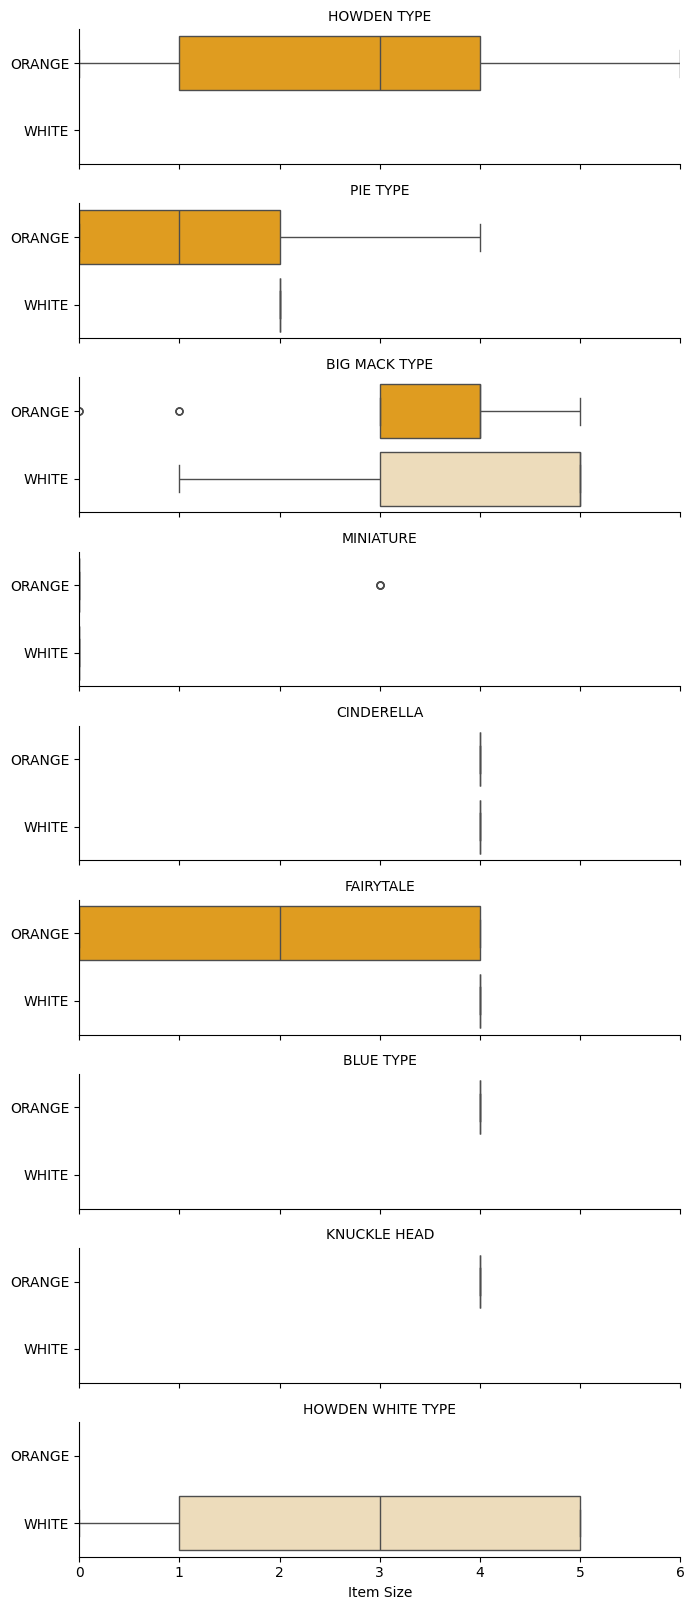

In [31]:
palette = {
    'ORANGE': 'orange',
    'WHITE': 'wheat',
}
# We need the encoded Item Size column to use it as the x-axis values in the plot
s_pumpkins['Item Size']= encoded_pumpkins['ord__Item Size']
plot = sns.catplot(
    data=s_pumpkins,
    x="Item Size",
    y="Color",
    row="Variety",
    kind="box",
    height=1.8,
    aspect=4,
    palette=palette,
    hue="Color",
    legend=False
)
# Defining axis labels
plot.set_axis_labels("Item Size", "")
plot.set(xlim=(0, 6))
plot.set_titles(row_template="{row_name}")

Let's now focus on a specific relationship: Item Size and Color!

In [32]:
import warnings
warnings.filterwarnings(action='ignore', category=UserWarning, module='seaborn')

<Axes: xlabel='Color', ylabel='ord__Item Size'>

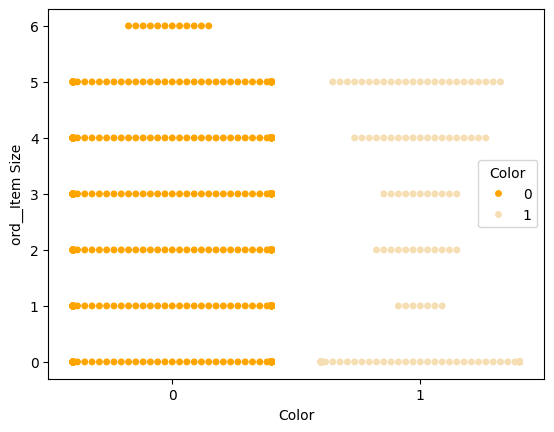

In [33]:
# Suppressing warning message claiming that a portion of points cannot be placed into the plot due to the high number of data points
import warnings
warnings.filterwarnings(action='ignore', category=UserWarning, module='seaborn')

palette = {
    0: 'orange',
    1: 'wheat'
}
sns.swarmplot(x="Color", y="ord__Item Size", hue="Color", data=encoded_pumpkins, palette=palette)

**Watch out**: Ignoring warnings is NOT a best practice and should be avoid, whenever possible. Warnings often contain useful messages that let us improve our code and solve an issue.
The reason why we are ignoring this specific warning is to guarantee the readability of the plot. Plotting all the data points with a reduced marker size, while keeping consistency with the palette color, generates an unclear visualization.

# Build your model

In [35]:
from sklearn.model_selection import train_test_split
# X is the encoded features
X = encoded_pumpkins.drop(columns=['Color'])
# y is the encoded label
y = encoded_pumpkins['Color']
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [36]:
from sklearn.metrics import f1_score, classification_report 
from sklearn.linear_model import LogisticRegression

# Train a logistic regression model on the pumpkin dataset
model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
# Evaluate the model and print the results

report = classification_report(y_test,predictions)
score = f1_score(y_test, predictions)
print(report)
print("f1_score:", score)


              precision    recall  f1-score   support

           0       0.94      0.98      0.96       166
           1       0.85      0.67      0.75        33

    accuracy                           0.92       199
   macro avg       0.89      0.82      0.85       199
weighted avg       0.92      0.92      0.92       199

f1_score: 0.7457627118644068


In [38]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
print(cm) 

[[162   4]
 [ 11  22]]
